# PCA Analysis on Gene Expression Data

This notebook performs Principal Component Analysis (PCA) on gene expression values
measured across multiple mice.  
Steps included:

1. Load and structure the dataset
2. Standardize the data
3. Run PCA
4. Visualize the results  
   - Biplot  
   - Loadings plot  
   - Scores plot  
5. Interpret findings


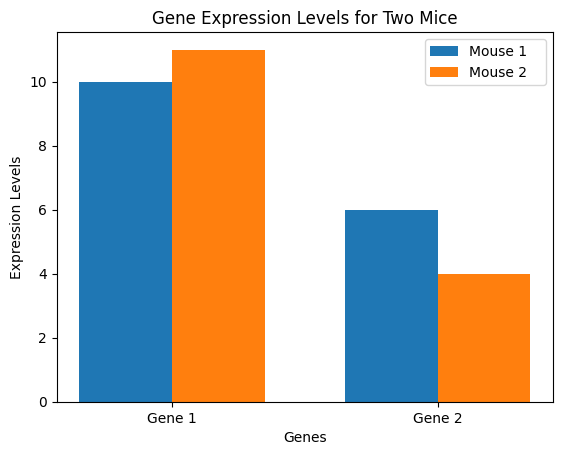

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data: 2 genen × 6 muizen
data = {
    "Mouse 1": [10, 6],
    "Mouse 2": [11, 4],
    "Mouse 3": [8,  5],
    "Mouse 4": [3,  3],
    "Mouse 5": [2,  2.8],
    "Mouse 6": [1,  1],
}
df = pd.DataFrame(data, index=["Gene 1", "Gene 2"]).T  # muizen als rijen
X = df.values.astype(float)

# centreren
X_centered = X - X.mean(axis=0)
n = X_centered.shape[0]

#plot original data staaf
fig, ax = plt.subplots()
bar_width = 0.35
index = np.arange(X.shape[1])
ax.bar(index, X[0], bar_width, label='Mouse 1')
ax.bar(index + bar_width, X[1], bar_width, label='Mouse 2   ')
ax.set_xlabel('Genes')
ax.set_ylabel('Expression Levels')
ax.set_title('Gene Expression Levels for Two Mice')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(['Gene 1', 'Gene 2'])
ax.legend()
plt.show()  

In [5]:
# x^2 + y^2 per muis (na centreren)
sq_lengths = np.sum(X_centered**2, axis=1)
total_sum_squares = sq_lengths.sum()
print(total_sum_squares)

print("Squared length per mouse:")
for i, val in enumerate(sq_lengths):
    print(f"Mouse {i+1}: {val:.4f}")

print("\nTotal sum of squares:", total_sum_squares)

# varianties van de genen
var_gene1 = X_centered[:,0].var(ddof=1)
var_gene2 = X_centered[:,1].var(ddof=1)

print("\nVariance Gene 1:", var_gene1)
print("Variance Gene 2:", var_gene2)
print("Sum of variances:", var_gene1 + var_gene2)

# totale variantie = totale sum of squares / (n-1)
total_variance = total_sum_squares / (n-1)
print("Total variance from sum of squares (n-1):", total_variance)


110.46666666666667
Squared length per mouse:
Mouse 1: 22.9622
Mouse 2: 26.8289
Mouse 3: 6.5622
Mouse 4: 8.4289
Mouse 5: 15.3889
Mouse 6: 30.2956

Total sum of squares: 110.46666666666667

Variance Gene 1: 18.96666666666667
Variance Gene 2: 3.1266666666666665
Sum of variances: 22.093333333333334
Total variance from sum of squares (n-1): 22.093333333333334


In [22]:
# Covariantiematrix S = (1/(n-1)) X^T X omdat X al gecentreerd is
S = np.dot(X_centered.T, X_centered) / (n - 1)
eigvals, eigvecs = np.linalg.eig(S)

# sorteren op grootte
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

explained_var_ratio = eigvals / eigvals.sum()

print("Covariance matrix S:\n", S)
print("\nEigenvalues (variances of PCs):", eigvals)
print("Explained variance ratio:", explained_var_ratio)


Covariance matrix S:
 [[18.96666667  6.48666667]
 [ 6.48666667  3.12666667]]

Eigenvalues (variances of PCs): [21.28401224  0.80932109]
Explained variance ratio: [0.96336809 0.03663191]


In [23]:
# scores in PC-ruimte
scores = np.dot(X_centered, eigvecs)
sq_lengths_pc = np.sum(scores**2, axis=1)

print("\nCheck Pythagoras voor/na rotatie:")
for i in range(n):
    print(f"Mouse {i+1}: original {sq_lengths[i]:.4f}, PC-space {sq_lengths_pc[i]:.4f}")



Check Pythagoras voor/na rotatie:
Mouse 1: original 22.9622, PC-space 22.9622
Mouse 2: original 26.8289, PC-space 26.8289
Mouse 3: original 6.5622, PC-space 6.5622
Mouse 4: original 8.4289, PC-space 8.4289
Mouse 5: original 15.3889, PC-space 15.3889
Mouse 6: original 30.2956, PC-space 30.2956


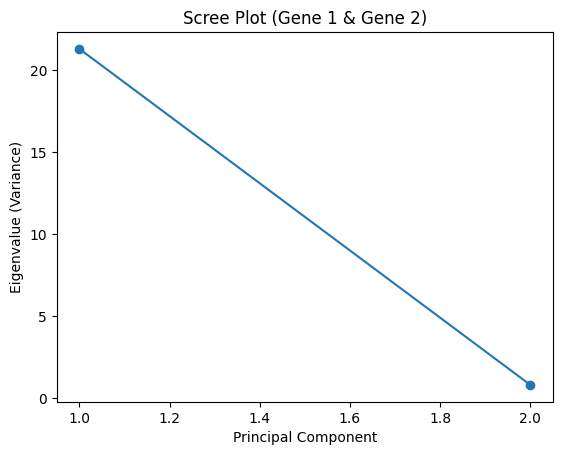

In [24]:
fig, ax = plt.subplots()
ax.plot(range(1, len(eigvals)+1), eigvals, marker='o')
ax.set_xlabel("Principal Component")
ax.set_ylabel("Eigenvalue (Variance)")
ax.set_title("Scree Plot (Gene 1 & Gene 2)")
plt.show()


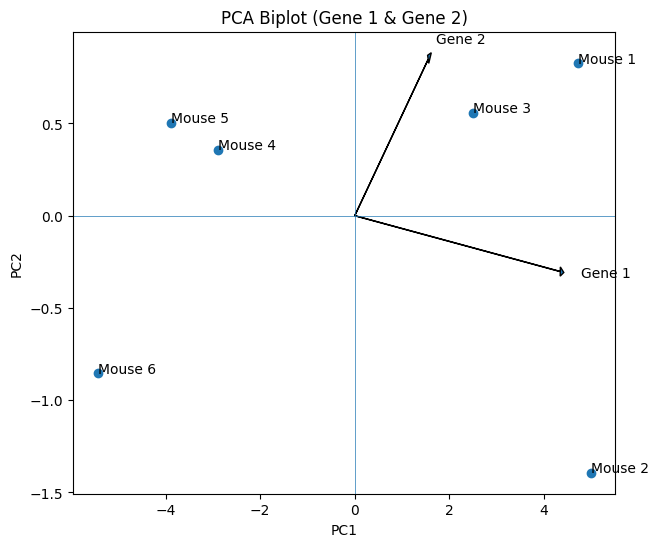

In [25]:
fig, ax = plt.subplots(figsize=(7,6))

# scores (PC1 vs PC2)
ax.scatter(scores[:,0], scores[:,1])
for i, name in enumerate(df.index):
    ax.text(scores[i,0], scores[i,1], name)

# loadings (eigenvectors * sqrt(eigenvalue) voor schaal)
loadings = eigvecs * np.sqrt(eigvals)

for j, gene in enumerate(df.columns):
    ax.arrow(0, 0, loadings[j,0], loadings[j,1], head_width=0.05)
    ax.text(loadings[j,0]*1.1, loadings[j,1]*1.1, gene)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA Biplot (Gene 1 & Gene 2)")
ax.axhline(0, linewidth=0.5)
ax.axvline(0, linewidth=0.5)
plt.show()
